# Setup

In [1]:
# Standard library imports
import os
import time
import warnings

# choose the numerical engine BEFORE keras is imported — this line must come first
os.environ['KERAS_BACKEND'] = 'torch'

# Third-party imports: core data
import numpy as np
import pandas as pd

# Third-party imports: deep learning (Keras 3 on the PyTorch backend)
import torch
import keras
from keras.models import Sequential, Model
from keras.layers import Input, Dense, GRU, RepeatVector, TimeDistributed
from keras.callbacks import EarlyStopping

# Third-party imports: preprocessing & metrics
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Third-party imports: visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)

print(f'keras {keras.__version__}, backend: {keras.backend.backend()}')

keras 3.15.0, backend: torch



This set of instructions prepares a Python environment for deep learning tasks, specifically time series forecasting using Keras with a PyTorch backend.

Initially, it imports necessary modules from the standard Python library – `os` for interacting with the operating system (like setting environment variables), `time` for time-related operations, and `warnings` to manage warning messages. 

Next, an important step is taken: the Keras backend is explicitly set to 'torch'. This must happen *before* importing Keras itself because it determines which deep learning framework Keras will use under the hood (in this case, PyTorch). The line `os.environ['KERAS_BACKEND'] = 'torch'` achieves this by setting an environment variable.

Following that, several third-party libraries are imported. `numpy` and `pandas` provide powerful tools for numerical computation and data manipulation, respectively.  The core Keras modules (`Sequential`, `Model`, `Input`, `Dense`, `GRU`, `RepeatVector`, `TimeDistributed`) are brought in to define and build neural network models. `EarlyStopping` is a callback function used during training to prevent overfitting. 

Additionally, libraries for more traditional machine learning (`Ridge` from scikit-learn) and evaluation metrics (`mean_squared_error`, `mean_absolute_error` from scikit-learn) are included. Finally, `matplotlib` is imported for creating visualizations of the data and model results.

The line `warnings.simplefilter(action='ignore', category=FutureWarning)` suppresses warnings related to future changes in Python or its libraries, keeping the output cleaner. 

Lastly, the code prints the versions of Keras being used and confirms that PyTorch is indeed the selected backend. This provides verification that the environment has been configured as intended.

In [2]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 16
    img_dim2 = 6
    SEED = 42
    LOOK_BACK = 28            # input window: four weeks of history per prediction
    HORIZON = 7               # forecast one week ahead in a single shot
    UNITS = 64                # width of the GRU hidden state
    SOURCE_STORE = 1          # data-rich source domain: all 50 items of this store
    TARGET_STORE = 10         # data-scarce target domain ...
    TARGET_ITEM = 15          # ... one item in a different store
    TARGET_HISTORY = 120      # days of target history we allow ourselves to see
    TEST_DAYS = 84            # final 12 weeks of the target series held out for testing
    PRETRAIN_EPOCHS = 8       # passes over the big source dataset
    PRETRAIN_BATCH = 256      # large batches for the large source set
    TARGET_EPOCHS = 200       # ceiling for target-side fits (early stopping decides)
    TARGET_BATCH = 32         # small batches for the small target set
    SOURCE_STRIDE = 2         # windowing stride on the source (thins overlapping windows)
    FT_LR = 1e-4              # gentle learning rate for fine-tuning pretrained weights

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

# reproducibility: seeds Python, NumPy and the deep learning backend in one call
keras.utils.set_random_seed(CFG.SEED)

This set of instructions defines configurations and initial settings for a time series forecasting project, likely involving transfer learning with recurrent neural networks (specifically GRUs).

The `CFG` class organizes various parameters. It specifies file paths for data (`data_folder`) and generated graphs (`graph_folder`). Image dimensions for visualization are set to 16x6 pixels (`img_dim1`, `img_dim2`). A random seed of 42 is established (`SEED`) to ensure reproducibility.

Key time series parameters include a look-back window of 28 days (`LOOK_BACK`), meaning the model uses four weeks of historical data for each prediction, and a forecast horizon of 7 days (`HORIZON`), indicating it predicts one week into the future. The GRU layer within the neural network will have 64 units (`UNITS`).

The code designates a source domain (store 1) with abundant data (`SOURCE_STORE`) and a target domain (store 10, item 15) where data is limited (`TARGET_STORE`, `TARGET_ITEM`). The amount of historical data used from the target domain is set to 120 days (`TARGET_HISTORY`), while the final 84 days are reserved for testing (`TEST_DAYS`).

Training parameters are also defined.  The source dataset will be used for pre-training the model over 8 epochs (`PRETRAIN_EPOCHS`) with a batch size of 256 (`PRETRAIN_BATCH`). The target domain training is capped at 200 epochs (`TARGET_EPOCHS`), but early stopping may terminate it sooner. A smaller batch size of 32 (`TARGET_BATCH`) is used for the target dataset.  A stride of 2 (`SOURCE_STRIDE`) is applied when creating windows from the source data, reducing overlap between them. Finally, a learning rate of 1e-4 (`FT_LR`) is set for fine-tuning the pre-trained model on the target domain.

Following the configuration settings, the code adjusts the plotting style using Seaborn (`plt.style.use("seaborn-v0_8")`) and sets a default figure size based on `img_dim1` and `img_dim2`. 

Lastly, it ensures reproducibility by setting random seeds for Python, NumPy, and Keras (`keras.utils.set_random_seed(CFG.SEED)`). This guarantees consistent results across multiple runs of the code.

In [3]:
# hardware: use the Apple silicon GPU when there is one, plain CPU otherwise
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'models will be created on: {DEVICE}')

models will be created on: mps


This portion of code determines which computational device will be used for running the machine learning model. 

It checks if Apple’s Metal Performance Shaders (MPS) backend is available in PyTorch, which indicates the presence of an Apple silicon GPU. If MPS is available, it assigns the string 'mps' to the `DEVICE` variable. Otherwise, it defaults to using the CPU by assigning 'cpu' to `DEVICE`. 

The code then prints a message indicating on which device models will be created, providing confirmation of the selected hardware. This allows users to quickly verify whether the GPU is being utilized for faster processing or if the program is falling back to the CPU.

# Utils

In [4]:
def forecast_metrics(y_true, y_pred):
    """Return MAE and RMSE between two aligned arrays, rounded for display."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': float(np.round(mae, 2)), 'RMSE': float(np.round(rmse, 2))}

This code defines a function called `forecast_metrics` that calculates and returns two common metrics used to evaluate the accuracy of time series forecasts: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The function takes two arguments, `y_true` and `y_pred`, which are expected to be arrays containing the actual (true) values and the predicted values, respectively. It’s assumed these arrays are aligned—meaning corresponding elements represent the same time point. 

Inside the function, it first calculates the MAE using the `mean_absolute_error` function from scikit-learn. Then, it computes the RMSE by calculating the square root of the mean squared error (obtained using `mean_squared_error` from scikit-learn).

Finally, the function returns a dictionary containing the calculated MAE and RMSE values. Both metrics are rounded to two decimal places using `np.round` and converted to floating-point numbers before being stored in the dictionary for clear presentation of results.

In [5]:
def make_windows(series, look_back, horizon, stride=1):
    """Slice a 1D array into (X, y) supervised pairs: look_back in, horizon out."""
    X, y = [], []
    for i in range(0, len(series) - look_back - horizon + 1, stride):
        X.append(series[i:i + look_back])
        y.append(series[i + look_back:i + look_back + horizon])
    X = np.array(X, dtype=np.float32).reshape(-1, look_back, 1)
    y = np.array(y, dtype=np.float32).reshape(-1, horizon)
    return X, y

This code defines a function called `make_windows` that prepares time series data for supervised learning, specifically for forecasting tasks. It transforms a one-dimensional array (a time series) into pairs of input sequences (X) and corresponding target values (y).

The function takes four arguments: the time series `series`, the length of the historical window to use as input (`look_back`), the number of steps ahead to predict (`horizon`), and an optional `stride` parameter that controls how much to shift the window for each step. The default stride is 1, meaning consecutive windows overlap by one data point.

The function initializes two empty lists, `X` and `y`, which will store the input sequences and target values respectively. It then iterates through the time series using a `for` loop with a specific range determined by `look_back`, `horizon`, and `stride`. 

Inside the loop, it extracts a segment of length `look_back` from the series starting at index `i` and appends it to the `X` list.  It then extracts the subsequent segment of length `horizon` (immediately following the input window) and appends it to the `y` list – this represents the target values we want to predict.

After processing the entire time series, the function converts the lists `X` and `y` into NumPy arrays with a data type of `np.float32`. It then reshapes these arrays to be suitable for input to a recurrent neural network (RNN) or similar model.  Specifically, `X` is reshaped to have dimensions (-1, `look_back`, 1), where -1 automatically infers the batch size and the last dimension of 1 represents a single feature. `y` is reshaped to (-1, `horizon`), representing batches of predicted values for each time step in the horizon.

Finally, the function returns the prepared input sequences `X` and target values `y`.

In [6]:
def make_test_windows(series, mean, std, test_days=CFG.TEST_DAYS):
    """Walk-forward test set: one origin per week, scaled inputs, labels in units."""
    z = ((series - mean) / std).to_numpy()      # inputs in the model's training scale
    raw = series.to_numpy()                     # labels stay in original units
    start = len(series) - test_days
    X, y = [], []
    for origin in range(start, len(series) - CFG.HORIZON + 1, CFG.HORIZON):
        X.append(z[origin - CFG.LOOK_BACK:origin])
        y.append(raw[origin:origin + CFG.HORIZON])
    X = np.array(X, dtype=np.float32).reshape(-1, CFG.LOOK_BACK, 1)
    return X, np.array(y, dtype=np.float32)

This code defines a function called `make_test_windows` that prepares data for walk-forward validation – a common technique for evaluating time series forecasting models. It creates test sets by sliding a window of historical data across the end of the time series, making predictions one week at a time.

The function takes the time series `series`, its mean and standard deviation (`mean`, `std`), and an optional number of test days (`test_days`) as input. The default value for `test_days` is taken from the global configuration object `CFG`.

First, it scales the entire time series by subtracting the mean and dividing by the standard deviation, storing the result in a NumPy array called `z`. This scaling ensures that the inputs to the model are within a similar range as those used during training. It also stores the original, unscaled data in a NumPy array named `raw`, which will be used for the target values (labels).

It then calculates the starting index (`start`) for creating the test windows based on the number of `test_days`. The code iterates through possible origins for each forecast window using a `for` loop.  The loop steps forward by `CFG.HORIZON` (one week) in each iteration, ensuring that each prediction is made one week ahead.

Inside the loop, it extracts a segment of length `CFG.LOOK_BACK` from the scaled series (`z`) starting at the current origin and appends it to the `X` list – this represents the input for the model. It then extracts the corresponding segment of length `CFG.HORIZON` from the original, unscaled series (`raw`) starting at the same origin and appends it to the `y` list – these are the actual values we want to predict (the labels).

After processing all possible origins, the function converts the lists `X` and `y` into NumPy arrays with a data type of `np.float32`. It reshapes `X` to have dimensions (-1, `CFG.LOOK_BACK`, 1) for compatibility with RNNs or similar models.

Finally, it returns the prepared input sequences `X` and target values `y`. The key difference from `make_windows` is that this function specifically prepares data for walk-forward validation using scaled inputs and original-scale labels, and it steps forward by the forecast horizon to simulate a real-world forecasting scenario.

In [7]:
def build_forecaster(units=CFG.UNITS, lr=1e-3):
    """GRU encoder + linear head, compiled for direct multi-step forecasting."""
    with keras.device(DEVICE):
        model = Sequential([
            Input(shape=(CFG.LOOK_BACK, 1)),
            GRU(units, name='encoder'),
            Dense(CFG.HORIZON, name='head'),
        ])
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=lr))
    return model

This code defines a function called `build_forecaster` that constructs a recurrent neural network (RNN) model for time series forecasting using Keras. Specifically, it builds a GRU-based encoder followed by a linear output layer.

The function takes two optional arguments: the number of units in the GRU layer (`units`), defaulting to the value specified in `CFG`, and the learning rate (`lr`) for the optimizer, defaulting to 1e-3.

Inside the function, it uses a `with keras.device(DEVICE):` block to ensure that the model is created on the appropriate device (GPU if available, otherwise CPU), as determined earlier by the `DEVICE` variable.

It then defines a sequential Keras model using `Sequential`. The model consists of three layers:
1.  An `Input` layer with a shape of (`CFG.LOOK_BACK`, 1). This specifies that the input to the model will be sequences of length `CFG.LOOK_BACK` with one feature (the time series value itself).
2.  A GRU (Gated Recurrent Unit) layer with `units` number of units, named 'encoder'. The GRU layer processes the input sequence and learns temporal dependencies.
3.  A Dense (fully connected) layer with `CFG.HORIZON` units, named 'head'. This layer maps the output of the GRU layer to a forecast for the next `CFG.HORIZON` time steps.

Finally, it compiles the model using the mean squared error (`mse`) loss function and the Adam optimizer with the specified learning rate (`lr`). The compiled model is then returned by the function. This resulting model is designed for direct multi-step forecasting – meaning it predicts all `CFG.HORIZON` future time steps in a single pass.

In [8]:
def fit_on(model, X_tr, y_tr, X_va, y_va, epochs=CFG.TARGET_EPOCHS,
           batch_size=CFG.TARGET_BATCH, patience=10, verbose=0):
    """Fit with early stopping on validation loss; return the History object."""
    early_stop = EarlyStopping(monitor='val_loss', patience=patience,
                               restore_best_weights=True)
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=[early_stop], verbose=verbose)
    print(f'stopped after {len(history.history["loss"])} epochs, '
          f'best val loss: {min(history.history["val_loss"]):.4f}')
    return history

This code defines a function called `fit_on` that trains a Keras model using the provided training and validation data, incorporating early stopping to prevent overfitting.

The function takes several arguments: the Keras model (`model`), the training input sequences (`X_tr`), the corresponding training target values (`y_tr`), the validation input sequences (`X_va`), the corresponding validation target values (`y_va`), the maximum number of epochs for training (`epochs`, defaulting to `CFG.TARGET_EPOCHS`), the batch size (`batch_size`, defaulting to `CFG.TARGET_BATCH`), the patience for early stopping (`patience`, defaulting to 10), and the verbosity level during training (`verbose`, defaulting to 0).

Inside the function, it creates an `EarlyStopping` callback that monitors the validation loss during training. If the validation loss does not improve for `patience` consecutive epochs, the training process will be stopped, and the model weights corresponding to the best validation loss encountered so far will be restored (`restore_best_weights=True`).

It then trains the model using the `fit` method of the Keras model. The training data is provided as `X_tr` and `y_tr`, and the validation data is provided as `(X_va, y_va)`. The training process runs for a maximum of `epochs` epochs with a batch size of `batch_size`. The `callbacks` argument includes the `early_stop` callback to enable early stopping.  The `verbose` argument controls the amount of output printed during training; setting it to 0 suppresses most output.

After training is complete (either by reaching the maximum number of epochs or by triggering the early stopping mechanism), the function prints a message indicating how many epochs were actually run and the best validation loss achieved during training, formatted to four decimal places.

Finally, the function returns the `history` object returned by the `fit` method. This object contains information about the training process, such as the loss and metrics values at each epoch for both the training and validation sets.

In [9]:
def evaluate_forecaster(model, X_test, y_true_units, mean, std):
    """Predict standardized test windows, convert back to units, score."""
    pred_units = model.predict(X_test, verbose=0) * std + mean
    return forecast_metrics(y_true_units.ravel(), pred_units.ravel())

This code defines a function called `evaluate_forecaster` that evaluates the performance of a trained forecasting model on a test dataset.

The function takes four arguments: the trained Keras model (`model`), the test input sequences (`X_test`), the true target values in their original units (`y_true_units`), and the mean and standard deviation used for scaling the data during training (`mean`, `std`).

Inside the function, it first makes predictions on the test data using the `predict` method of the model. The `verbose=0` argument suppresses output during prediction.  The predicted values are initially in standardized units (i.e., scaled by subtracting the mean and dividing by the standard deviation). To convert them back to the original units, it multiplies the predictions by the standard deviation (`std`) and adds the mean (`mean`). The result is stored in `pred_units`.

Finally, it calls the `forecast_metrics` function (defined previously) to calculate the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) between the flattened true target values (`y_true_units.ravel()`) and the flattened predicted values (`pred_units.ravel()`). The resulting dictionary containing the MAE and RMSE is then returned by the function, providing a measure of the model's forecasting accuracy on the test set.

In [10]:
def plot_test_forecasts(observed, forecasts, title):
    """Overlay observed test data with one or more stitched weekly forecasts.

    observed:  pd.Series over the test period (original units)
    forecasts: dict of label -> array (n_weeks, HORIZON) in original units
    """
    plt.figure()
    observed.plot(linewidth=2, label='observed', xlabel="")
    colors = ['red', 'green', 'purple', 'orange']
    for (label, preds), color in zip(forecasts.items(), colors):
        stitched = pd.Series(np.asarray(preds).ravel()[:len(observed)],
                             index=observed.index)
        stitched.plot(linestyle='--', marker='o', markersize=3,
                      color=color, label=label)
    plt.title(title)
    plt.ylabel('units sold')
    plt.legend()
    plt.show()

This code defines a function called `plot_test_forecasts` that visualizes the performance of a forecasting model by plotting observed test data alongside its forecasts.

The function takes two arguments: `observed`, which is a Pandas Series representing the actual values during the test period (in original units), and `forecasts`, which is a dictionary containing one or more sets of forecast predictions. The keys of the dictionary are labels for each set of forecasts, and the values are NumPy arrays with shape (number of weeks, `CFG.HORIZON`) representing the weekly forecasts in original units.  The third argument, `title`, provides a title for the plot.

Inside the function, it creates a new Matplotlib figure using `plt.figure()`. It then plots the observed data as a line with a linewidth of 2 and labels it 'observed', removing the x-axis label to avoid clutter.

It iterates through the forecasts in the `forecasts` dictionary using `zip(forecasts.items(), colors)`, pairing each forecast set (label, predictions) with a color from a predefined list (`colors`). For each forecast set:
1.  It stitches together the weekly forecasts into a single Pandas Series called `stitched`. It uses `np.asarray(preds).ravel()[:len(observed)]` to flatten the array of forecasts and truncate it to the length of the observed data, ensuring that only the relevant portion of the forecast is plotted. The index of the stitched series is set to match the index of the observed series.
2.  It plots the `stitched` series as a dashed line with markers ('o') of size 3, using the assigned color and labeling it with the corresponding label from the dictionary.

Finally, it sets the title of the plot to the provided `title`, labels the y-axis as 'units sold', displays a legend to identify the observed data and each forecast set, and shows the plot using `plt.show()`. This function provides a clear visual comparison between the actual test data and the model's predictions.

# Groundwork

In [11]:
# load the raw panel and carve out the two domains
raw = pd.read_csv(CFG.data_folder + 'train.csv', parse_dates=['date'])

# source: store 1, all 50 items, as a (days x items) matrix
source_panel = (raw[raw.store == CFG.SOURCE_STORE]
                .pivot(index='date', columns='item', values='sales'))

# target: one item in a different store, as a single series
target = (raw[(raw.store == CFG.TARGET_STORE) & (raw.item == CFG.TARGET_ITEM)]
          .set_index('date')['sales'])

print(f'source panel: {source_panel.shape[0]} days x {source_panel.shape[1]} items')
print(f'target series: {len(target)} days, {target.index.min().date()} to {target.index.max().date()}')
source_panel.head(3)

source panel: 1826 days x 50 items
target series: 1826 days, 2013-01-01 to 2017-12-31


item,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,13,33,15,10,11,31,25,33,18,37,...,6,21,22,20,37,30,17,21,18,30
2013-01-02,11,43,30,11,6,36,23,37,23,34,...,15,24,27,15,40,30,15,26,10,32
2013-01-03,14,23,14,8,8,18,34,38,25,32,...,5,14,19,11,42,30,5,25,17,25


This code loads and prepares the time series data for a transfer learning experiment, separating it into source and target domains.

First, it reads the training data from a CSV file specified by `CFG.data_folder + 'train.csv'` using Pandas' `read_csv` function. The `parse_dates=['date']` argument ensures that the 'date' column is parsed as datetime objects.  The resulting DataFrame is stored in the variable `raw`.

Next, it creates a source panel representing data from store 1 and all 50 items. It filters the `raw` DataFrame to include only rows where the 'store' column equals `CFG.SOURCE_STORE` (which is set to 1). Then, it uses the `pivot` function to reshape the data into a matrix with dates as the index, items as columns, and sales as values. This creates a panel-like structure where each row represents a day and each column represents an item's sales in that store. The resulting source panel is stored in the variable `source_panel`.

Then, it extracts the target time series representing data from a specific item in a different store. It filters the `raw` DataFrame to include only rows where the 'store' column equals `CFG.TARGET_STORE` (10) and the 'item' column equals `CFG.TARGET_ITEM` (15).  It then sets the 'date' column as the index of the resulting DataFrame and selects only the 'sales' column, creating a Pandas Series representing the sales time series for that specific item in that store. The result is stored in the variable `target`.

Finally, it prints information about the shape of the source panel (number of days and items) and the length and date range of the target series to provide an overview of the data. It also displays the first three rows of the `source_panel` DataFrame using `.head(3)` for a quick inspection of its contents. This prepares the data into two distinct datasets: a rich source domain with many items and a sparse target domain with only one item, suitable for transfer learning techniques.

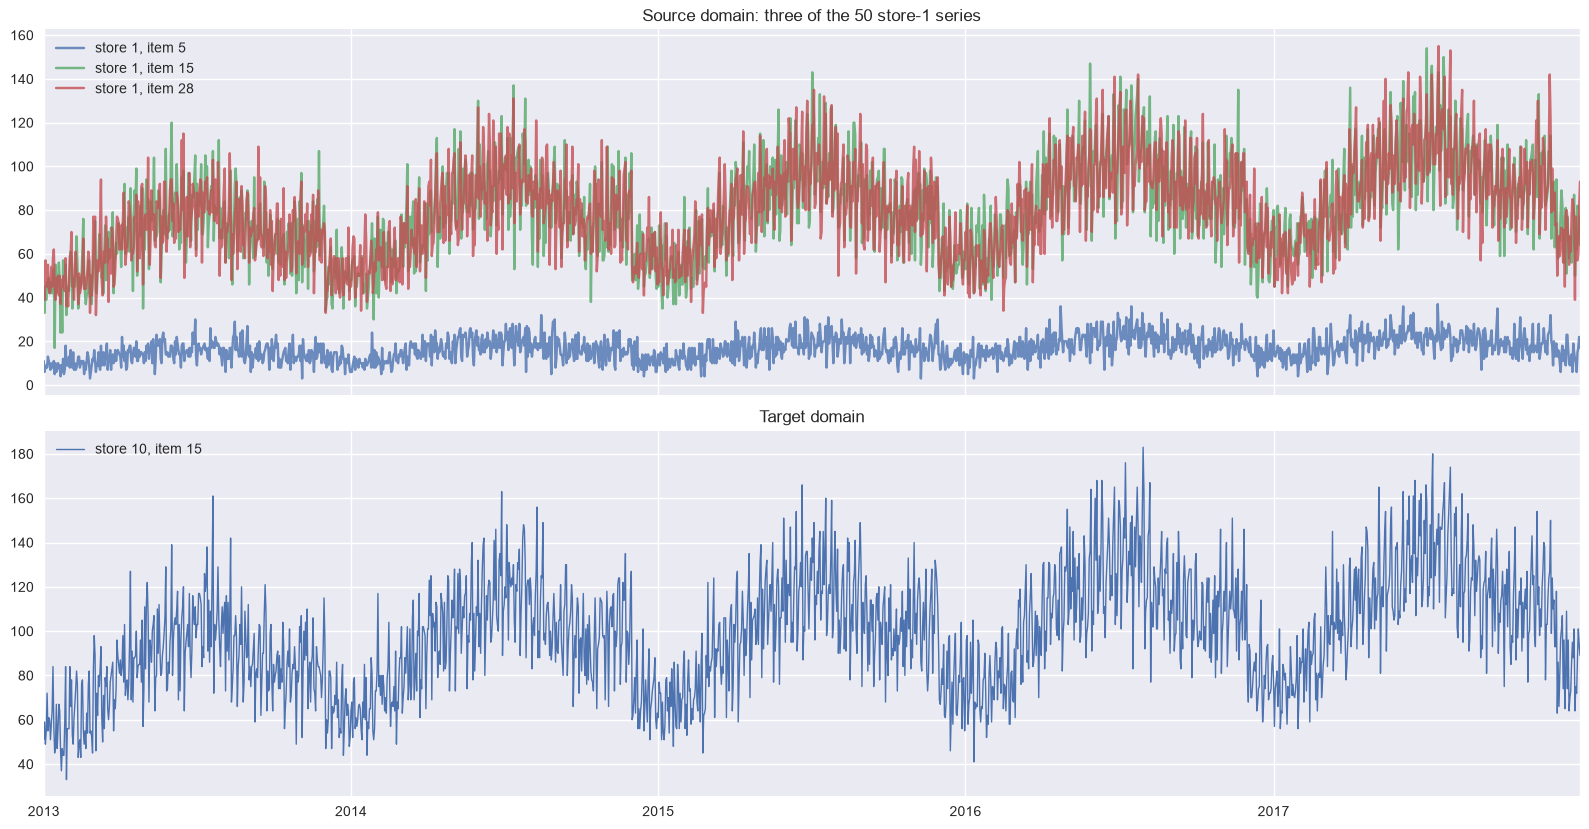

In [12]:
# a first look at both domains
fig, axes = plt.subplots(2, 1, figsize=(CFG.img_dim1, CFG.img_dim2 * 1.4), sharex=True)

# top: a few source series
for item in [5, 15, 28]:
    source_panel[item].plot(ax=axes[0], alpha=0.8, label=f'store 1, item {item}')
axes[0].set_title('Source domain: three of the 50 store-1 series')
axes[0].legend()

# bottom: the target series
target.plot(ax=axes[1], linewidth=1, label=f'store 10, item {CFG.TARGET_ITEM}')
axes[1].set_title('Target domain')
axes[1].set_xlabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

This code generates a visualization to provide an initial comparison between the source and target time series data.

It first creates a figure with two subplots arranged vertically using `plt.subplots`. The `figsize` argument sets the overall size of the figure based on the dimensions defined in `CFG`, and `sharex=True` ensures that both subplots share the same x-axis (date).

The top subplot (`axes[0]`) displays a few sample time series from the source domain. It iterates through a list of item IDs ([5, 15, 28]) and plots the corresponding sales data from the `source_panel` for each item on the same subplot using different alpha values (transparency) to distinguish them. Each line is labeled with the store and item number. A title 'Source domain: three of the 50 store-1 series' is added, and a legend is displayed to identify each time series.

The bottom subplot (`axes[1]`) displays the target time series. It plots the `target` Series on this subplot with a linewidth of 1 and labels it appropriately. A title 'Target domain' is added, and the x-axis label is removed to avoid redundancy since it’s shared with the top plot. A legend is also displayed for clarity.

Finally, `plt.tight_layout()` adjusts the spacing between subplots to prevent overlapping elements, and `plt.show()` displays the resulting figure. This visualization allows a quick assessment of the characteristics of both datasets – the source domain's diversity across multiple items and the target domain’s single time series – helping to understand the challenges and potential benefits of transfer learning in this context.

scarce train: 2017-06-11 to 2017-10-08 (120 days)
test:         2017-10-09 to 2017-12-31 (84 days)


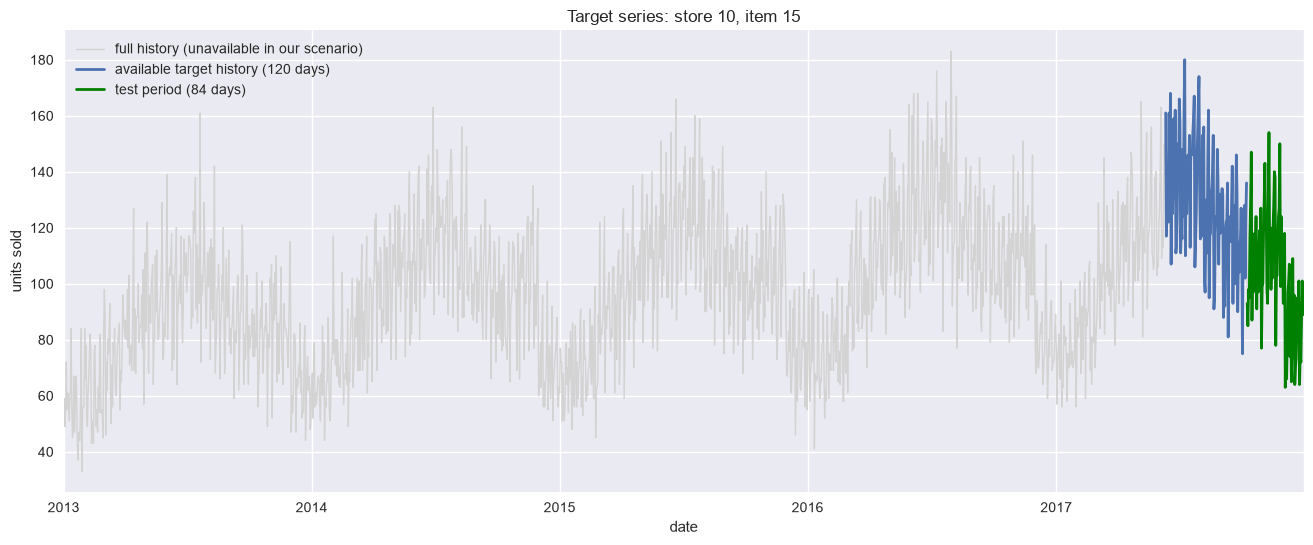

In [13]:
# chronological carve-up of the target: (ignored history | 120-day train | 84-day test)
test = target.iloc[-CFG.TEST_DAYS:]
history = target.iloc[:-CFG.TEST_DAYS]
scarce = history.iloc[-CFG.TARGET_HISTORY:]

print(f'scarce train: {scarce.index.min().date()} to {scarce.index.max().date()} ({len(scarce)} days)')
print(f'test:         {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)')

# visualize the split
plt.figure()
target.plot(linewidth=1, color='lightgray', label='full history (unavailable in our scenario)')
scarce.plot(linewidth=2, label='available target history (120 days)')
test.plot(linewidth=2, color='green', label='test period (84 days)')
plt.title(f'Target series: store {CFG.TARGET_STORE}, item {CFG.TARGET_ITEM}')
plt.ylabel('units sold')
plt.legend()
plt.show()

This code divides the target time series into three segments: a portion representing ignored historical data, a training set with limited history (`scarce`), and a test set for evaluating model performance. This simulates a realistic scenario where only a short period of historical data is available for the target domain.

First, it splits the `target` Series into two parts: `test` and `history`. The `test` segment consists of the last `CFG.TEST_DAYS` (84) days of the series, representing the hold-out test set. The remaining portion is assigned to `history`, representing all data before the test period.

Next, it further divides the `history` segment into two parts: a longer historical segment that's considered unavailable for training and the `scarce` training set.  The `scarce` segment consists of the last `CFG.TARGET_HISTORY` (120) days of the `history` series, representing the limited amount of target domain data available for training.

It then prints information about the date ranges and lengths of both the `scarce` training set and the `test` set to confirm the split.

Finally, it creates a visualization to illustrate the division of the target time series. It plots the entire `target` Series in light gray as a reference (labeled 'full history (unavailable in our scenario)'), the `scarce` training set in a thicker line (labeled 'available target history (120 days)'), and the `test` set in green (labeled 'test period (84 days)'). A title is added indicating the store and item number, and the y-axis is labeled as 'units sold'.  A legend clarifies which segment corresponds to each line. This plot visually demonstrates how a limited amount of target domain data is used for training while reserving a separate test set for evaluation.

In [14]:
# standardize using ONLY the scarce training history, then window
t_mean, t_std = scarce.mean(), scarce.std()
print(f'target scaling stats (from the 120 training days only): mean={t_mean:.1f}, std={t_std:.1f}')

scarce_z = ((scarce - t_mean) / t_std).to_numpy()
X_target, y_target = make_windows(scarce_z, CFG.LOOK_BACK, CFG.HORIZON)

# chronological train/validation split of the windows
N_VAL = max(8, int(0.2 * len(X_target)))
X_tr, y_tr = X_target[:-N_VAL], y_target[:-N_VAL]
X_va, y_va = X_target[-N_VAL:], y_target[-N_VAL:]

print(f'target windows: {len(X_target)} total = {len(X_tr)} train + {len(X_va)} validation')
print(f'input tensor: {X_tr.shape}, labels: {y_tr.shape}')

target scaling stats (from the 120 training days only): mean=128.3, std=21.2
target windows: 86 total = 69 train + 17 validation
input tensor: (69, 28, 1), labels: (69, 7)


This code prepares the target time series data for training a forecasting model by standardizing it using statistics calculated *only* from the limited available training history and then creating supervised learning windows.

First, it calculates the mean (`t_mean`) and standard deviation (`t_std`) of the `scarce` Series (the 120-day target training data). It’s crucial to use only this data for standardization because we want to simulate a realistic scenario where information about the entire time series is not available during training. The calculated mean and standard deviation are printed for inspection.

Next, it standardizes the `scarce` Series by subtracting the calculated mean (`t_mean`) and dividing by the standard deviation (`t_std`). This scaled data is stored in a NumPy array called `scarce_z`.

It then calls the `make_windows` function (defined earlier) to transform the standardized time series (`scarce_z`) into supervised learning pairs of input sequences (X) and target values (y). The `CFG.LOOK_BACK` and `CFG.HORIZON` parameters determine the length of the input window and the forecast horizon, respectively.  The resulting input sequences are stored in `X_target`, and the corresponding target values are stored in `y_target`.

Finally, it splits the created windows into training and validation sets. It calculates the number of validation samples (`N_VAL`) as 20% of the total number of windows, with a minimum value of 8 to ensure sufficient data for validation.  It then divides `X_target` and `y_target` into training sets (`X_tr`, `y_tr`) containing all but the last `N_VAL` samples and validation sets (`X_va`, `y_va`) containing the last `N_VAL` samples, maintaining chronological order.

The code concludes by printing information about the number of windows in each set (total, train, and validation) and the shape of the input tensor (`X_tr`) and labels (`y_tr`), confirming that the data is properly prepared for training. This ensures that the model is trained and validated on a representative subset of the limited target domain data while respecting the temporal order of the time series.

In [15]:
# test windows: walk-forward, one forecast origin per week, labels kept in units
X_test, y_test_units = make_test_windows(target, t_mean, t_std)
print(f'test windows: {X_test.shape[0]} weekly origins, inputs {X_test.shape}, labels {y_test_units.shape}')

test windows: 12 weekly origins, inputs (12, 28, 1), labels (12, 7)


This code prepares the test data for evaluating the forecasting model using a walk-forward approach, ensuring that predictions are made one week at a time and that the target values remain in their original units.

It calls the `make_test_windows` function (defined previously) to create the test set. The function takes the original `target` Series, the mean (`t_mean`) and standard deviation (`t_std`) calculated from the scarce training data, and uses these statistics for scaling the input features during testing. This is important because it ensures consistency between the training and testing phases – the test inputs are scaled using the same parameters as the training inputs.

The `make_test_windows` function returns two NumPy arrays: `X_test`, which contains the standardized input sequences (historical data) for each forecast origin, and `y_test_units`, which contains the corresponding target values (actual sales) in their original units.

Finally, it prints information about the shape of the test set, indicating the number of weekly forecast origins (`X_test.shape[0]`), the shape of the input sequences (`X_test.shape`), and the shape of the target values (`y_test_units.shape`). This confirms that the test data is properly prepared for evaluating the model's forecasting performance in a realistic walk-forward manner, with labels remaining in their original units for easier interpretation.

In [16]:
# two naive baselines every method must beat
results = {}

# persistence: tomorrow (and the next 6 days) = today
persistence = np.repeat(X_test[:, -1, 0].reshape(-1, 1), CFG.HORIZON, axis=1) * t_std + t_mean
results['persistence'] = forecast_metrics(y_test_units.ravel(), persistence.ravel())

# seasonal naive: next week = last week
seasonal_naive_pred = X_test[:, -CFG.HORIZON:, 0] * t_std + t_mean
results['seasonal naive'] = forecast_metrics(y_test_units.ravel(), seasonal_naive_pred.ravel())

print('persistence:   ', results['persistence'])
print('seasonal naive:', results['seasonal naive'])

persistence:    {'MAE': 24.14, 'RMSE': 29.04}
seasonal naive: {'MAE': 13.61, 'RMSE': 17.97}


This code establishes two simple baseline forecasting methods – persistence and seasonal naiveté – against which the performance of more complex models will be compared.

It initializes an empty dictionary called `results` to store the evaluation metrics for each method.

First, it implements a *persistence* model, which predicts that tomorrow's value will be equal to today's value (and extends this prediction for the entire forecast horizon). It extracts the last value from each input sequence in `X_test` (`X_test[:, -1, 0]`), reshapes it to have one column, and then repeats this value `CFG.HORIZON` times to create a forecast for the next week. The standardized predictions are then converted back to original units by multiplying by `t_std` and adding `t_mean`.  The performance of this persistence model is evaluated using the `forecast_metrics` function, with the results stored in the `results` dictionary under the key 'persistence'.

Next, it implements a *seasonal naiveté* model, which predicts that next week's values will be equal to the corresponding values from last week. It extracts the last `CFG.HORIZON` values from each input sequence in `X_test` (`X_test[:, -CFG.HORIZON:, 0]`), converts them back to original units, and uses these as the forecast for the next week. The performance of this seasonal naiveté model is evaluated using `forecast_metrics`, with the results stored in the `results` dictionary under the key 'seasonal naive'.

Finally, it prints the evaluation metrics (MAE and RMSE) for both baseline models to provide a benchmark for assessing the effectiveness of more sophisticated forecasting techniques. Any model that cannot outperform these simple baselines is likely not providing meaningful improvements.

# The transfer learning ladder

## Rung 1: from scratch on the target

In [17]:
keras.utils.set_random_seed(CFG.SEED)

scratch_model = build_forecaster()
print(f'parameters: {scratch_model.count_params():,} '
      f'(encoder {scratch_model.get_layer("encoder").count_params():,}, '
      f'head {scratch_model.get_layer("head").count_params():,})')

fit_on(scratch_model, X_tr, y_tr, X_va, y_va)
results['from scratch'] = evaluate_forecaster(scratch_model, X_test, y_test_units, t_mean, t_std)
print('from scratch:', results['from scratch'])

parameters: 13,319 (encoder 12,864, head 455)
stopped after 59 epochs, best val loss: 0.5089
from scratch: {'MAE': 15.82, 'RMSE': 20.05}


This code trains a forecasting model from scratch (without pre-training) and evaluates its performance.

First, it sets the random seed for Keras to `CFG.SEED` to ensure reproducibility of the training process.

It then builds a new GRU-based forecasting model using the `build_forecaster` function. This creates a model with randomly initialized weights. The code prints the total number of trainable parameters in the model, as well as the number of parameters in the encoder (GRU layer) and head (Dense layer), providing insight into the model's complexity.

Next, it trains the newly created model using the `fit_on` function, passing in the training data (`X_tr`, `y_tr`), validation data (`X_va`, `y_va`), and default training parameters defined in `CFG`. This process adjusts the model’s weights to minimize the loss function on the training data while monitoring performance on the validation set.

After training, it evaluates the trained model's performance on the test data using the `evaluate_forecaster` function. The evaluation metrics (MAE and RMSE) are stored in the `results` dictionary under the key 'from scratch'.

Finally, it prints the evaluation results for the model trained from scratch, allowing comparison with the baseline models and the pre-trained model (if one is also evaluated). This step assesses how well a model can perform when learning solely from the limited target domain data without any prior knowledge transfer.

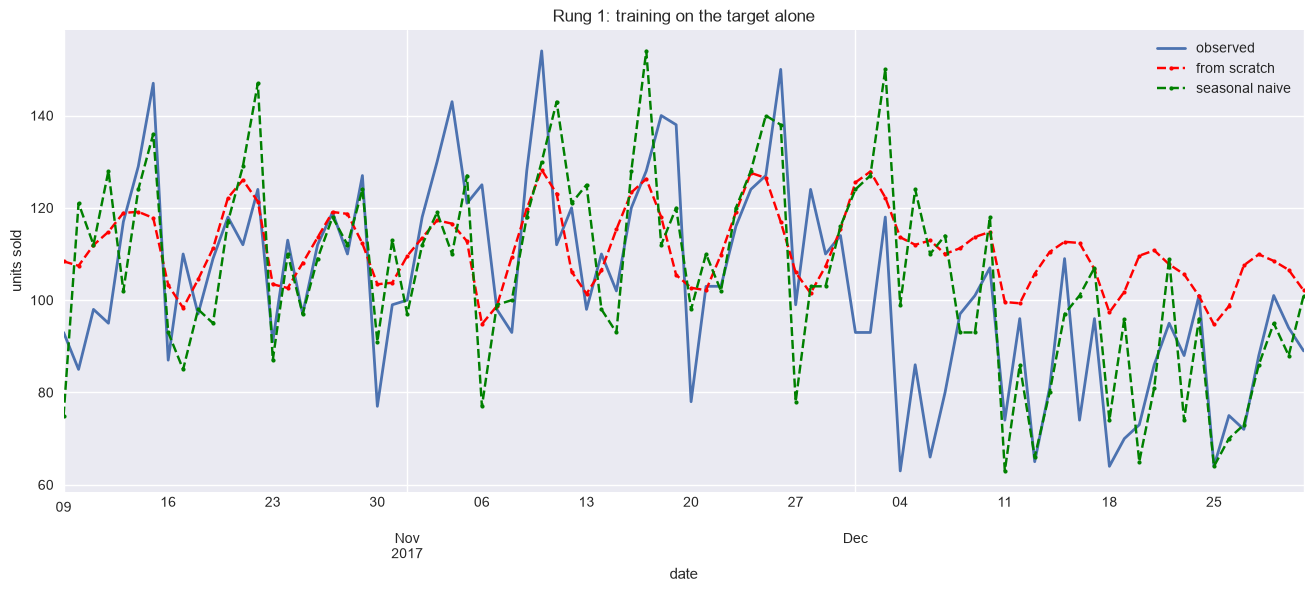

In [18]:
scratch_pred = scratch_model.predict(X_test, verbose=0) * t_std + t_mean
plot_test_forecasts(test, {'from scratch': scratch_pred,
                           'seasonal naive': seasonal_naive_pred},
                    'Rung 1: training on the target alone')

This code generates a visualization comparing the forecasts produced by the model trained from scratch with those of the seasonal naiveté baseline.

It first obtains predictions from the `scratch_model` using the test input sequences (`X_test`). The `verbose=0` argument suppresses output during prediction.  The standardized predictions are then converted back to original units by multiplying by `t_std` and adding `t_mean`. These predictions are stored in the variable `scratch_pred`.

Next, it calls the `plot_test_forecasts` function to create a visualization comparing the actual test data (`test`) with the forecasts from both the model trained from scratch ('from scratch') and the seasonal naiveté baseline ('seasonal naive'). The function receives a dictionary containing the predictions for each method.

Finally, the plot is displayed with the title 'Rung 1: training on the target alone', indicating that this visualization represents the results of training a model solely on the limited target domain data. This allows for a visual assessment of how well the model trained from scratch performs relative to the baseline and provides insights into its ability to capture patterns in the target time series.

## Rung 2: supervised pretraining and zero-shot transfer

In [19]:
# build the source training set: window each store-1 series in its own scale
VAL_TAIL = 120   # last 120 days of each source series held out for validation

X_src_tr, y_src_tr, X_src_va, y_src_va = [], [], [], []
for item in source_panel.columns:
    series = source_panel[item].iloc[:-CFG.TEST_DAYS]          # align with target test period
    m, s = series.mean(), series.std()
    z = ((series - m) / s).to_numpy()
    Xa, ya = make_windows(z[:-VAL_TAIL], CFG.LOOK_BACK, CFG.HORIZON, stride=CFG.SOURCE_STRIDE)
    Xb, yb = make_windows(z[-VAL_TAIL:], CFG.LOOK_BACK, CFG.HORIZON, stride=CFG.SOURCE_STRIDE)
    X_src_tr.append(Xa); y_src_tr.append(ya)
    X_src_va.append(Xb); y_src_va.append(yb)

X_src_tr = np.concatenate(X_src_tr); y_src_tr = np.concatenate(y_src_tr)
X_src_va = np.concatenate(X_src_va); y_src_va = np.concatenate(y_src_va)
print(f'source windows: {len(X_src_tr):,} train, {len(X_src_va):,} validation')

source windows: 39,700 train, 2,150 validation


This code prepares the source domain data for pre-training the forecasting model. It creates training and validation sets by windowing each individual time series (representing sales of a specific item in store 1) independently, scaling each series using its own mean and standard deviation.

First, it defines `VAL_TAIL` as 120, indicating that the last 120 days of each source time series will be held out for validation.

It then initializes four empty lists: `X_src_tr`, `y_src_tr`, `X_src_va`, and `y_src_va`. These lists will store the input sequences (X) and target values (y) for the source training and validation sets, respectively.

The code iterates through each item (column) in the `source_panel` DataFrame. For each item:
1.  It extracts the corresponding time series from the panel. It truncates the series to align with the test period of the target data by removing the last `CFG.TEST_DAYS` days.
2.  It calculates the mean (`m`) and standard deviation (`s`) of the current item's time series.
3.  It standardizes the time series by subtracting the mean and dividing by the standard deviation, storing the result in a NumPy array called `z`.
4.  It uses the `make_windows` function to create supervised learning pairs (X, y) from the standardized time series. It splits the data into training and validation sets based on the `VAL_TAIL`: the first part (`z[:-VAL_TAIL]`) is used for training, and the last 120 days (`z[-VAL_TAIL:]`) are used for validation. A stride of `CFG.SOURCE_STRIDE` is applied to create overlapping windows.
5.  The resulting training and validation windows (Xa, ya) and (Xb, yb) are appended to the corresponding lists (`X_src_tr`, `y_src_tr`, `X_src_va`, `y_src_va`).

After processing all items in the source panel, it concatenates the lists of training windows (`X_src_tr`, `y_src_tr`) and validation windows (`X_src_va`, `y_src_va`) into single NumPy arrays. This combines the data from all 50 items into a larger training and validation set.

Finally, it prints the number of training and validation windows in the source dataset to provide an overview of the size of the pre-training data. The key aspect here is that each item’s time series is standardized independently before windowing, allowing the model to learn patterns specific to each item's scale.

In [ ]:
keras.utils.set_random_seed(CFG.SEED)
pretrained_model = build_forecaster()

start = time.time()
pretrained_model.fit(X_src_tr, y_src_tr,
                     validation_data=(X_src_va, y_src_va),
                     epochs=CFG.PRETRAIN_EPOCHS, batch_size=CFG.PRETRAIN_BATCH,
                     verbose=2)
print(f'pretraining took {time.time() - start:.0f} s')

pretrained_weights = pretrained_model.get_weights()

Epoch 1/8
156/156 - 2s - 12ms/step - loss: 0.5394 - val_loss: 0.6258
Epoch 2/8
156/156 - 2s - 11ms/step - loss: 0.4292 - val_loss: 0.4967
Epoch 3/8


This code pre-trains the forecasting model on the source domain data and saves the learned weights for later use in fine-tuning.

First, it sets the random seed for Keras to `CFG.SEED` to ensure reproducibility of the pre-training process.

It then builds a new GRU-based forecasting model using the `build_forecaster` function. This creates a model with randomly initialized weights that will be updated during pre-training.

Next, it trains the model on the source domain data (`X_src_tr`, `y_src_tr`) and validates its performance on the source validation set (`X_src_va`, `y_src_va`). The training process runs for `CFG.PRETRAIN_EPOCHS` epochs with a batch size of `CFG.PRETRAIN_BATCH`.  The `verbose=2` argument enables detailed output during training, showing the progress of each epoch.

It measures and prints the time taken for pre-training to provide an indication of computational cost.

Finally, it extracts the learned weights from the trained model using the `get_weights` method and stores them in the variable `pretrained_weights`. These weights represent the knowledge gained from training on the large source dataset and will be used to initialize the weights of the model when fine-tuning on the target domain data. This transfer learning approach aims to leverage the information learned from the source domain to improve performance on the limited target domain data.

In [ ]:
# zero-shot: apply the source model to the target, no adaptation whatsoever
results['zero-shot transfer'] = evaluate_forecaster(pretrained_model, X_test,
                                                    y_test_units, t_mean, t_std)
print('zero-shot transfer:', results['zero-shot transfer'])

This code evaluates the performance of the pre-trained model on the target test data *without any further training or adaptation*. This is known as a "zero-shot" transfer learning scenario.

It calls the `evaluate_forecaster` function, passing in the pre-trained model (`pretrained_model`), the test input sequences from the target domain (`X_test`), the true target values in their original units (`y_test_units`), and the mean and standard deviation used for scaling the target data (`t_mean`, `t_std`).

The `evaluate_forecaster` function calculates the MAE and RMSE between the model's predictions on the test set and the actual target values. The resulting evaluation metrics are stored in the `results` dictionary under the key 'zero-shot transfer'.

Finally, it prints the evaluation results for the zero-shot transfer scenario. This provides a baseline to assess how much improvement can be achieved by fine-tuning the pre-trained model on the target domain data. It demonstrates the extent to which the knowledge learned from the source domain generalizes to the target domain without any adaptation.

## Rung 3: fine-tune the head only


In [ ]:
keras.utils.set_random_seed(CFG.SEED)

head_ft_model = build_forecaster()
head_ft_model.set_weights(pretrained_weights)          # transplant ALL pretrained weights
head_ft_model.get_layer('encoder').trainable = False   # ... then freeze the encoder
head_ft_model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=1e-3))

trainable = sum(int(np.prod(w.shape)) for w in head_ft_model.trainable_weights)
print(f'trainable parameters after freezing: {trainable} of {head_ft_model.count_params():,}')

fit_on(head_ft_model, X_tr, y_tr, X_va, y_va)
results['head-only fine-tune'] = evaluate_forecaster(head_ft_model, X_test,
                                                     y_test_units, t_mean, t_std)
print('head-only fine-tune:', results['head-only fine-tune'])

This code performs a "head-only" fine-tuning of the pre-trained model on the target domain data. This involves freezing the weights of the encoder (GRU layer) and only training the output layer (Dense layer).

First, it sets the random seed for Keras to `CFG.SEED` to ensure reproducibility.

It then builds a new GRU-based forecasting model using the `build_forecaster` function. This creates a model with the same architecture as the pre-trained model.

Next, it transplants the weights learned during pre-training from the `pretrained_weights` variable into the newly built model using `head_ft_model.set_weights(pretrained_weights)`. This initializes the model with the knowledge gained from the source domain.

Crucially, it freezes the encoder (GRU layer) by setting its `trainable` attribute to `False`. This prevents the weights of the GRU layer from being updated during fine-tuning, preserving the features learned from the source data. Only the output layer (Dense layer), referred to as the "head," will be trained.

It recompiles the model with a learning rate of 1e-3 for the Adam optimizer.

The code then calculates and prints the number of trainable parameters in the model after freezing the encoder, providing insight into how much of the model is being updated during fine-tuning. This confirms that only the weights of the output layer are being trained.

It trains the head-only fine-tuned model using the `fit_on` function with the target domain training and validation data (`X_tr`, `y_tr`, `X_va`, `y_va`).

Finally, it evaluates the performance of the fine-tuned model on the test set using the `evaluate_forecaster` function. The evaluation metrics are stored in the `results` dictionary under the key 'head-only fine-tune', and the results are printed to the console. This allows for comparison with the zero-shot transfer result and assesses the effectiveness of fine-tuning only the output layer while preserving the learned features from the source domain.

## Rung 4 — full fine-tuning

In [ ]:
keras.utils.set_random_seed(CFG.SEED)

full_ft_model = build_forecaster(lr=CFG.FT_LR)      # note: gentle learning rate
full_ft_model.set_weights(pretrained_weights)

fit_on(full_ft_model, X_tr, y_tr, X_va, y_va)
results['full fine-tune'] = evaluate_forecaster(full_ft_model, X_test,
                                                y_test_units, t_mean, t_std)
print('full fine-tune:', results['full fine-tune'])

This code performs a full fine-tuning of the pre-trained model on the target domain data. This involves unfreezing all layers and training the entire network with a gentle learning rate.

First, it sets the random seed for Keras to `CFG.SEED` to ensure reproducibility.

It then builds a new GRU-based forecasting model using the `build_forecaster` function, specifying the fine-tuning learning rate (`CFG.FT_LR`) as an argument. This creates a model with the same architecture as the pre-trained model but uses a smaller learning rate for updating the weights during fine-tuning to avoid disrupting the knowledge gained from pre-training too much.

Next, it transplants the weights learned during pre-training from the `pretrained_weights` variable into the newly built model using `full_ft_model.set_weights(pretrained_weights)`. This initializes the model with the knowledge gained from the source domain.  Unlike the head-only fine-tuning, all layers remain trainable in this case.

It trains the fully fine-tuned model using the `fit_on` function with the target domain training and validation data (`X_tr`, `y_tr`, `X_va`, `y_va`). The gentle learning rate helps to adapt the pre-trained weights to the specific characteristics of the target domain without drastically altering them.

Finally, it evaluates the performance of the fine-tuned model on the test set using the `evaluate_forecaster` function. The evaluation metrics are stored in the `results` dictionary under the key 'full fine-tune', and the results are printed to the console. This allows for comparison with the zero-shot transfer result, the head-only fine-tuning result, and assesses the effectiveness of fully adapting the pre-trained model to the target domain data.

In [ ]:
full_ft_pred = full_ft_model.predict(X_test, verbose=0) * t_std + t_mean
plot_test_forecasts(test, {'from scratch': scratch_pred,
                           'full fine-tune': full_ft_pred},
                    'Rung 4: what pretraining buys')

This code generates a visualization comparing the forecasts produced by the model trained from scratch with those of the fully fine-tuned model.

It first obtains predictions from the `full_ft_model` using the test input sequences (`X_test`). The `verbose=0` argument suppresses output during prediction.  The standardized predictions are then converted back to original units by multiplying by `t_std` and adding `t_mean`. These predictions are stored in the variable `full_ft_pred`.

Next, it calls the `plot_test_forecasts` function to create a visualization comparing the actual test data (`test`) with the forecasts from both the model trained from scratch ('from scratch') and the fully fine-tuned model ('full fine-tune'). The function receives a dictionary containing the predictions for each method.

Finally, the plot is displayed with the title 'Rung 4: what pretraining buys', indicating that this visualization aims to demonstrate the benefits of using transfer learning (pre-training) compared to training a model from scratch on the limited target domain data. This allows for a visual assessment of how much improvement can be achieved by leveraging knowledge learned from the source domain through fine-tuning.

## Rung 5: self-supervised pretraining: the masked autoencoder

In [ ]:
MASK_FRAC = 0.4   # fraction of timesteps zeroed out in each window
DEMO_IDX = 230    # a shoulder-season window, for plots

rng = np.random.default_rng(CFG.SEED)
mask = rng.random(X_src_tr.shape) < MASK_FRAC
X_src_masked = X_src_tr.copy()
X_src_masked[mask] = 0.0

# what the pretext task looks like: one window, intact vs. corrupted
plt.figure()
plt.plot(X_src_tr[DEMO_IDX].ravel(), linewidth=2, label='original window')
plt.plot(X_src_masked[DEMO_IDX].ravel(), 'ro--', linewidth=1, markersize=4, label='masked input (40% zeroed)')
plt.title('The pretext task: reconstruct the original from the corrupted version')
plt.xlabel('day within window')
plt.ylabel('standardized sales')
plt.legend()
plt.show()

This code prepares data for a self-supervised pretraining task, specifically masking portions of the input time series windows to force the model to learn robust representations. It also visualizes an example of this masked input.

First, it defines `MASK_FRAC` as 0.4, indicating that 40% of the values within each window will be zeroed out (masked). It also sets `DEMO_IDX` to 230, which represents the index of a specific window in the source training data that will be used for visualization purposes.

It then initializes a NumPy random number generator using `np.random.default_rng(CFG.SEED)` to ensure reproducibility.  A boolean mask is created with the same shape as `X_src_tr` (the source training input sequences). The mask contains `True` values at locations where a random number is less than `MASK_FRAC`, and `False` otherwise.

A copy of `X_src_tr` is made to avoid modifying the original data, stored in `X_src_masked`.  The elements of `X_src_masked` corresponding to `True` values in the mask are set to 0.0, effectively zeroing out a fraction of the input values in each window.

Finally, it generates a visualization illustrating the masking process. It plots one example window from the original source training data (`X_src_tr[DEMO_IDX]`) as a solid line and the corresponding masked window (`X_src_masked[DEMO_IDX]`) as a dashed red line with markers. The plot is titled 'The pretext task: reconstruct the original from the corrupted version', indicating that the goal of this pretraining task is to learn to reconstruct the original, uncorrupted time series from its masked counterpart.  Labels are added for clarity and axes are labeled appropriately. This visualization helps understand how the model will be challenged during self-supervised pretraining – it must learn to infer missing information based on the remaining context within each window.

In [ ]:
keras.utils.set_random_seed(CFG.SEED)

with keras.device(DEVICE):
    autoencoder = Sequential([
        Input(shape=(CFG.LOOK_BACK, 1)),
        GRU(CFG.UNITS, name='encoder'),          # same encoder shape as the forecaster
        RepeatVector(CFG.LOOK_BACK),             # broadcast the code across 28 steps
        GRU(CFG.UNITS, return_sequences=True),   # decoder
        TimeDistributed(Dense(1)),               # per-step reconstruction
    ])
autoencoder.compile(loss='mse', optimizer='adam')

start = time.time()
autoencoder.fit(X_src_masked, X_src_tr, epochs=CFG.PRETRAIN_EPOCHS,
                batch_size=CFG.PRETRAIN_BATCH, verbose=2)
print(f'masked-autoencoder pretraining took {time.time() - start:.0f} s')

This code builds and trains an autoencoder model for self-supervised pretraining on the masked source data. The goal is to learn a compressed representation of the time series that can be used to reconstruct the original, unmasked input.

First, it sets the random seed for Keras to `CFG.SEED` to ensure reproducibility.

It then defines an autoencoder model using Keras's sequential API within a `with keras.device(DEVICE):` block to specify the device (GPU if available). The autoencoder consists of:
1.  An `Input` layer with shape (`CFG.LOOK_BACK`, 1), accepting time series windows as input.
2.  A GRU encoder layer with `CFG.UNITS` units, named 'encoder'. This layer compresses the input sequence into a fixed-length vector representation (the "code"). It uses the same encoder shape as the forecasting model to facilitate transfer learning.
3.  A `RepeatVector` layer that repeats the code vector `CFG.LOOK_BACK` times, effectively broadcasting it across all time steps of the output sequence. This prepares the code for decoding.
4.  A GRU decoder layer with `CFG.UNITS` units and `return_sequences=True`. This layer takes the repeated code as input and generates a sequence of outputs with the same length as the input sequence.
5.  A `TimeDistributed(Dense(1))` layer that applies a dense (fully connected) layer to each time step of the output sequence, reconstructing the original values.

The autoencoder is compiled using the mean squared error (`mse`) loss function and the Adam optimizer.

Next, it trains the autoencoder on the masked source data (`X_src_masked`) with the goal of reconstructing the original unmasked data (`X_src_tr`). The training process runs for `CFG.PRETRAIN_EPOCHS` epochs with a batch size of `CFG.PRETRAIN_BATCH`.  The `verbose=2` argument enables detailed output during training.

Finally, it measures and prints the time taken for pretraining to provide an indication of computational cost. The trained autoencoder learns to reconstruct the original input from its masked version, forcing it to learn meaningful representations that capture the underlying patterns in the data. These learned weights will be used later for initializing the forecasting model.

In [ ]:
# how well does it infill? one source validation window
demo_masked = X_src_va[:1].copy()
demo_rng = np.random.default_rng(7)
demo_masked[demo_rng.random(demo_masked.shape) < MASK_FRAC] = 0.0
recon = autoencoder.predict(demo_masked, verbose=0)

plt.figure()
plt.plot(X_src_va[0].ravel(), linewidth=2, label='original')
plt.plot(demo_masked[0].ravel(), 'o--', color='gray', markersize=4, label='masked input')
plt.plot(recon[0].ravel(), 'r', linewidth=2, label='reconstruction')
plt.title('Masked autoencoder: reconstruction on an unseen window')
plt.xlabel('day within window')
plt.ylabel('standardized sales')
plt.legend()
plt.show()

This code demonstrates the autoencoder's ability to reconstruct masked input data by visualizing its performance on a single validation window from the source domain.

First, it selects the first window from the source validation set (`X_src_va[:1]`) and makes a copy to avoid modifying the original data, storing it in `demo_masked`.

It then initializes a NumPy random number generator with seed 7 using `np.random.default_rng(7)` for reproducibility. It applies the same masking process as during training – randomly setting values in `demo_masked` to zero based on the `MASK_FRAC` (40%).

Next, it uses the trained autoencoder to predict the reconstruction of the masked input (`demo_masked`). The `verbose=0` argument suppresses output during prediction. The reconstructed window is stored in `recon`.

Finally, it generates a visualization comparing the original window, the masked input, and the reconstructed output. It plots the original window as a solid line, the masked input as dashed gray circles, and the reconstruction as a solid red line. A title 'Masked autoencoder: reconstruction on an unseen window' is added, along with labels for each line and appropriate axis labels. This plot allows visual assessment of how well the autoencoder can infill the missing data based on the context provided by the unmasked portions of the input sequence.

In [ ]:
# transplant the SSL encoder, then fine-tune in two stages
keras.utils.set_random_seed(CFG.SEED)

ssl_model = build_forecaster()
ssl_model.get_layer('encoder').set_weights(autoencoder.get_layer('encoder').get_weights())

# stage 1: warm up the (random) head with the encoder frozen
ssl_model.get_layer('encoder').trainable = False
ssl_model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=1e-3))
fit_on(ssl_model, X_tr, y_tr, X_va, y_va)

# stage 2: unfreeze everything at the gentle rate
ssl_model.get_layer('encoder').trainable = True
ssl_model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=CFG.FT_LR))
fit_on(ssl_model, X_tr, y_tr, X_va, y_va)

results['masked AE + fine-tune'] = evaluate_forecaster(ssl_model, X_test,
                                                       y_test_units, t_mean, t_std)
print('masked AE + fine-tune:', results['masked AE + fine-tune'])

This code implements a two-stage fine-tuning process for the forecasting model, leveraging the encoder weights learned during self-supervised pretraining with the masked autoencoder.

First, it sets the random seed for Keras to `CFG.SEED` to ensure reproducibility.

It then builds a new GRU-based forecasting model using the `build_forecaster` function. It transplants the weights from the encoder layer of the trained autoencoder into the encoder layer of the forecasting model using `ssl_model.get_layer('encoder').set_weights(autoencoder.get_layer('encoder').get_weights())`. This initializes the forecasting model's encoder with the knowledge gained during self-supervised pretraining.

**Stage 1: Warm up the head.** The code freezes the weights of the encoder layer by setting `ssl_model.get_layer('encoder').trainable = False`. It then recompiles the model with a learning rate of 1e-3 for the Adam optimizer, preparing it for training only the output layer (the "head").  It trains the model using the `fit_on` function with the target domain training and validation data. This stage aims to quickly adapt the randomly initialized head to the features extracted by the pre-trained encoder without disrupting the learned representations.

**Stage 2: Unfreeze and fine-tune.** The code unfreezes the encoder layer by setting `ssl_model.get_layer('encoder').trainable = True`. It recompiles the model with a gentle learning rate (`CFG.FT_LR`) for the Adam optimizer, allowing for gradual adjustments to all weights in the network.  It trains the entire model using the `fit_on` function again with the target domain training and validation data. This stage fine-tunes both the encoder and head layers to optimize performance on the target task.

Finally, it evaluates the performance of the fully fine-tuned model on the test set using the `evaluate_forecaster` function. The evaluation metrics are stored in the `results` dictionary under the key 'masked AE + fine-tune', and the results are printed to the console. This allows for comparison with other approaches and assesses the effectiveness of leveraging self-supervised pretraining followed by a two-stage fine-tuning process.

## Rung 6:  contrastive pretraining

In [ ]:
def augment(X, rng):
    """A random view of each window: amplitude scaling + additive jitter."""
    scale = rng.uniform(0.8, 1.2, (X.shape[0], 1, 1)).astype(np.float32)
    jitter = rng.normal(0.0, 0.1, X.shape).astype(np.float32)
    return X * scale + jitter

view_1 = augment(X_src_tr, np.random.default_rng(1))
view_2 = augment(X_src_tr, np.random.default_rng(2))

# two views of the same source window
plt.figure()
plt.plot(X_src_tr[DEMO_IDX].ravel(), linewidth=2, label='original window')
plt.plot(view_1[DEMO_IDX].ravel(), '--', color='red', label='view 1')
plt.plot(view_2[DEMO_IDX].ravel(), '--', color='green', label='view 2')
plt.title('Contrastive pretraining: a positive pair')
plt.xlabel('day within window')
plt.ylabel('standardized sales')
plt.legend()
plt.show()

This code defines an augmentation function and generates two different "views" of the source training data for use in contrastive self-supervised learning.

First, it defines a function called `augment` that takes input data `X` and a random number generator `rng` as arguments. This function applies two types of augmentations to each window in the input:
1.  **Amplitude scaling:** It generates random scale factors between 0.8 and 1.2 for each window using `rng.uniform`. These scale factors are then applied to the windows by multiplying them element-wise.
2.  **Additive jitter:** It generates random noise with a normal distribution (mean 0, standard deviation 0.1) using `rng.normal` and adds it to the windows.

The function returns the augmented data.

Next, it creates two different views of the source training data (`X_src_tr`) by applying the `augment` function twice with different random seeds (1 and 2). This generates two slightly perturbed versions of the same data, which will be treated as a "positive pair" during contrastive learning.

Finally, it generates a visualization to illustrate the augmentation process. It plots one example window from the original source training data (`X_src_tr[DEMO_IDX]`) as a solid line, and then plots the corresponding augmented views (`view_1[DEMO_IDX]` and `view_2[DEMO_IDX]`) as dashed lines with different colors. A title 'Contrastive pretraining: a positive pair' is added to indicate that these two views are considered similar examples for contrastive learning, and appropriate axis labels are included. This visualization demonstrates how the augmentation function creates slightly different versions of the same data, which will be used to train the model to learn invariant representations.

In [ ]:
EMB_DIM = 64        # dimension of the projection the loss operates on
TEMPERATURE = 0.2   # sharpness of the softmax over similarities

keras.utils.set_random_seed(CFG.SEED)   # re-seed BEFORE building: reproducible init

with keras.device(DEVICE):
    # the encoder we intend to keep, plus a projection layer used only during pretraining
    enc_input = Input(shape=(CFG.LOOK_BACK, 1))
    embedding = GRU(CFG.UNITS, name='encoder')(enc_input)
    projection = Dense(EMB_DIM)(embedding)
    contrastive_encoder = Model(enc_input, projection)

    # siamese wrapper: one encoder applied to both views
    input_a = Input(shape=(CFG.LOOK_BACK, 1))
    input_b = Input(shape=(CFG.LOOK_BACK, 1))
    paired = keras.ops.stack([contrastive_encoder(input_a),
                              contrastive_encoder(input_b)], axis=1)
    contrastive_model = Model([input_a, input_b], paired)


def nt_xent(y_true, y_pred):
    """Normalized temperature-scaled cross-entropy (the SimCLR loss)."""
    z1 = keras.ops.normalize(y_pred[:, 0, :], axis=1)
    z2 = keras.ops.normalize(y_pred[:, 1, :], axis=1)
    z = keras.ops.concatenate([z1, z2], axis=0)                    # (2N, d)
    sim = keras.ops.matmul(z, keras.ops.transpose(z)) / TEMPERATURE
    n = keras.ops.shape(z1)[0]
    sim = sim - keras.ops.eye(2 * n) * 1e9                         # exclude self-matches
    targets = keras.ops.concatenate(
        [keras.ops.arange(n, 2 * n), keras.ops.arange(0, n)], axis=0)
    return keras.ops.mean(
        keras.losses.sparse_categorical_crossentropy(targets, sim, from_logits=True))

This code defines a contrastive learning model for self-supervised pretraining, along with the associated loss function (NT-Xent). The goal is to learn representations that are invariant to the augmentations applied to the input data.

First, it sets the random seed for Keras to `CFG.SEED` to ensure reproducibility of the model initialization.

It then builds a contrastive encoder using Keras's functional API within a `with keras.device(DEVICE):` block. The encoder consists of:
1.  An `Input` layer with shape (`CFG.LOOK_BACK`, 1), accepting time series windows as input.
2.  A GRU layer with `CFG.UNITS` units, named 'encoder'. This layer extracts features from the input sequence.
3.  A Dense layer that projects the output of the GRU layer to a lower-dimensional embedding space (`EMB_DIM`). This projection is used only during pretraining and helps to reduce computational cost and improve generalization.

The encoder is encapsulated in a `Model` object, taking the input window as input and producing the embedded representation as output.

Next, it creates a Siamese network wrapper that applies the contrastive encoder to two different views of the same input data. It defines two separate input layers (`input_a`, `input_b`), each with shape (`CFG.LOOK_BACK`, 1).  It then passes both inputs through the `contrastive_encoder` and stacks the resulting embeddings along a new axis (axis=1) using `keras.ops.stack`. This creates a tensor containing the embeddings of both views for each input sample. The Siamese network is encapsulated in a `Model` object, taking two input windows as input and producing their paired embeddings as output.

Finally, it defines a custom loss function called `nt_xent`, which implements the Normalized Temperature-scaled Cross Entropy (NT-Xent) loss - a common loss function used in contrastive learning frameworks like SimCLR. The loss function takes two arguments: `y_true` and `y_pred`. It normalizes the embeddings from both views (`z1` and `z2`) using `keras.ops.normalize`, calculates the cosine similarity between all pairs of embeddings, scales the similarities by a temperature parameter (`TEMPERATURE`), excludes self-matches (by setting diagonal elements to a large negative value), and then computes the sparse categorical cross-entropy loss based on the assumption that each view should be most similar to its corresponding augmented view. The function returns the mean NT-Xent loss over all samples in the batch.

This setup prepares the model for contrastive learning, where it will learn to pull embeddings of different views of the same data closer together while pushing embeddings of different data points further apart.

In [ ]:
contrastive_model.compile(loss=nt_xent, optimizer='adam')

# labels are irrelevant — the loss uses only y_pred — but fit() requires something
dummy_y = np.zeros((len(X_src_tr), 1), dtype=np.float32)

start = time.time()
contrastive_model.fit([view_1, view_2], dummy_y,
                      epochs=CFG.PRETRAIN_EPOCHS, batch_size=CFG.PRETRAIN_BATCH,
                      verbose=2)
print(f'contrastive pretraining took {time.time() - start:.0f} s')

This code trains the contrastive learning model on the augmented source data using the defined NT-Xent loss function.

First, it compiles the `contrastive_model` with the custom `nt_xent` loss function and the Adam optimizer.

Since the NT-Xent loss only depends on the predicted embeddings (`y_pred`) and not on any explicit labels (`y_true`), a dummy target variable is created using `np.zeros`. This satisfies Keras's requirement for a target variable during training, even though it won’t be used in the loss calculation.

Next, it trains the contrastive model using the `fit` method. The input data consists of two views of the source training data: `view_1` and `view_2`. These are passed as a list to the `fit` method because the model has two inputs (the Siamese network structure). The dummy target variable (`dummy_y`) is also provided.  The training process runs for `CFG.PRETRAIN_EPOCHS` epochs with a batch size of `CFG.PRETRAIN_BATCH`. The `verbose=2` argument enables detailed output during training, showing the progress of each epoch.

Finally, it measures and prints the time taken for contrastive pretraining to provide an indication of computational cost. This step trains the model to learn representations that are invariant to the augmentations applied to the input data, enabling it to capture meaningful features from the source domain without relying on explicit labels.

In [ ]:
# frozen contrastive encoder -> ridge regression head on the target
feature_extractor = Model(enc_input, embedding)   # up to the GRU, skipping the projection

F_train = feature_extractor.predict(X_target, verbose=0)   # all 86 target windows
F_test = feature_extractor.predict(X_test, verbose=0)

ridge_head = Ridge(alpha=1.0).fit(F_train, y_target)
ridge_pred_units = ridge_head.predict(F_test) * t_std + t_mean

results['contrastive + ridge head'] = forecast_metrics(y_test_units.ravel(),
                                                       ridge_pred_units.ravel())
print('contrastive + ridge head:', results['contrastive + ridge head'])

This code utilizes the pre-trained contrastive encoder as a feature extractor and trains a simple Ridge regression model on top of those features to make predictions on the target domain.

First, it creates a new `Model` called `feature_extractor`. This model takes the same input shape as the original encoder (`enc_input`) but only includes the GRU layer (up to the embedding layer), excluding the projection layer used during contrastive pretraining.  This effectively freezes the weights of the GRU encoder and uses it to extract features from the target data.

It then extracts features from both the training (`X_target`) and test (`X_test`) sets using the `feature_extractor`. The `predict` method is called with `verbose=0` to suppress output during prediction.  The resulting feature matrices are stored in `F_train` and `F_test`, respectively.

Next, it trains a Ridge regression model on the extracted training features (`F_train`) and corresponding target values (`y_target`). The `Ridge` class from scikit-learn is used with an alpha value of 1.0 (regularization strength).  The trained Ridge regression model is stored in `ridge_head`.

It then uses the trained Ridge regression model to predict on the extracted test features (`F_test`). The predictions are scaled back to the original units by multiplying by `t_std` and adding `t_mean`, storing the result in `ridge_pred_units`.

Finally, it evaluates the performance of the combined contrastive encoder + Ridge regression model using the `forecast_metrics` function. The evaluation metrics (MAE and RMSE) are stored in the `results` dictionary under the key 'contrastive + ridge head', and the results are printed to the console. This approach leverages the learned representations from the contrastive pretraining stage by using them as input features for a simple linear model, allowing it to adapt to the target domain without further training of the encoder itself.

# When does transfer help?

## The sample-efficiency curve


In [ ]:
HISTORIES = [60, 120, 240, 480]   # days of target history made available

sample_eff = {}
for n_days in HISTORIES:
    chunk = history.iloc[-n_days:]
    m, s = chunk.mean(), chunk.std()
    X_h, y_h = make_windows(((chunk - m) / s).to_numpy(), CFG.LOOK_BACK, CFG.HORIZON)
    n_va = max(6, int(0.2 * len(X_h)))

    # test inputs re-scaled with THIS history's statistics; labels are unchanged
    X_te_h, _ = make_test_windows(target, m, s)

    row = {}
    for method in ['from scratch', 'full fine-tune']:
        keras.utils.set_random_seed(CFG.SEED)
        model = build_forecaster(lr=1e-3 if method == 'from scratch' else CFG.FT_LR)
        if method == 'full fine-tune':
            model.set_weights(pretrained_weights)
        fit_on(model, X_h[:-n_va], y_h[:-n_va], X_h[-n_va:], y_h[-n_va:], verbose=0)
        row[method] = evaluate_forecaster(model, X_te_h, y_test_units, m, s)['RMSE']
    sample_eff[n_days] = row
    print(f'{n_days:4d} days of target history -> {row}')

sample_eff_df = pd.DataFrame(sample_eff).T.rename_axis('target history (days)')
sample_eff_df

This code investigates the impact of varying amounts of target domain historical data on forecasting performance, evaluating both a model trained from scratch and a fine-tuned pre-trained model for each history length.

First, it defines a list `HISTORIES` containing different lengths of target history (60, 120, 240, and 480 days) to be evaluated.

It then iterates through each value in the `HISTORIES` list:
1.  **Data Selection:** For each `n_days`, it extracts a chunk of the `history` Series containing only the last `n_days` of data. This represents the amount of target history available for training.
2.  **Scaling:** It calculates the mean (`m`) and standard deviation (`s`) of this historical chunk. These statistics will be used to scale both the training and test data for that specific history length, ensuring consistency.
3.  **Windowing:** It uses the `make_windows` function to create supervised learning pairs (X, y) from the scaled historical data.
4.  **Validation Split:** It calculates the number of validation samples (`n_va`) as 20% of the total number of windows, with a minimum value of 6.
5.  **Test Data Preparation:** It uses `make_test_windows` to create test input sequences (`X_te_h`), scaling them using the mean and standard deviation calculated from *this* specific historical chunk. The labels remain in their original units.

Inside the loop, it evaluates two forecasting methods:
   - **From Scratch:** A new model is built using `build_forecaster` with a learning rate of 1e-3. It's trained on the training data (`X_h[:-n_va]`, `y_h[:-n_va]`) and validated on the validation data (`X_h[-n_va:]`, `y_h[-n_va:]`).
   - **Full Fine-Tune:** A new model is built using `build_forecaster` with a learning rate of `CFG.FT_LR`. The weights from the pre-trained model are loaded into this new model. It's then trained and validated in the same way as the "from scratch" model.

For each method, it evaluates performance on the test data using `evaluate_forecaster` and extracts only the RMSE score, storing it in a dictionary called `row`. The results for both methods are stored in a dictionary called `sample_eff`, with the history length (`n_days`) as the key and the `row` dictionary (containing RMSE scores) as the value.

Finally, it prints the results for each history length and creates a Pandas DataFrame from the `sample_eff` dictionary, transposing it so that rows represent different history lengths and columns represent different methods. The index of the DataFrame is set to 'target history (days)'. This allows for easy comparison of performance across different amounts of target domain historical data and between models trained from scratch and fine-tuned from a pre-trained model.

In [ ]:
plt.figure()
sample_eff_df['from scratch'].plot(marker='o', linewidth=2, label='from scratch')
sample_eff_df['full fine-tune'].plot(marker='o', linewidth=2, color='green', label='full fine-tune')
plt.axhline(results['seasonal naive']['RMSE'], color='red', linestyle='--',
            label=f"seasonal naive ({results['seasonal naive']['RMSE']})")
plt.title('Sample efficiency: test RMSE vs. available target history')
plt.xlabel('days of target history')
plt.ylabel('test RMSE (units sold)')
plt.legend()
plt.show()

This code generates a plot visualizing the sample efficiency of the two forecasting methods – training from scratch and full fine-tuning – as a function of the amount of available target domain historical data.

It creates a new Matplotlib figure using `plt.figure()`. It then plots the RMSE scores for the "from scratch" method from the `sample_eff_df` DataFrame as a line with circular markers, a linewidth of 2, and a default color. Similarly, it plots the RMSE scores for the "full fine-tune" method as a line with circular markers, a linewidth of 2, and the color green.

A horizontal dashed red line is added to the plot representing the RMSE score of the seasonal naive baseline. The label for this line includes both the text "seasonal naive" and its corresponding RMSE value. This provides a reference point for evaluating the performance of the two learning methods.

The plot is titled 'Sample efficiency: test RMSE vs. available target history', with appropriate labels for the x-axis ('days of target history') and y-axis ('test RMSE (units sold)'). A legend is added to identify each line on the plot.

Finally, `plt.show()` displays the generated plot, allowing visual assessment of how performance changes as more target domain historical data becomes available and comparing the sample efficiency of training from scratch versus fine-tuning a pre-trained model. The goal is to determine which method requires less target data to achieve comparable or better forecasting accuracy than the baseline.

## Negative transfer

In [ ]:
# pretrain on weather, evaluate on store demand
temps = pd.read_csv(CFG.data_folder + 'daily-min-temperatures.csv', parse_dates=['Date'])
temps_z = ((temps.Temp - temps.Temp.mean()) / temps.Temp.std()).to_numpy()
X_weather, y_weather = make_windows(temps_z, CFG.LOOK_BACK, CFG.HORIZON)
print(f'weather windows: {len(X_weather):,}')

keras.utils.set_random_seed(CFG.SEED)
weather_model = build_forecaster()
weather_model.fit(X_weather, y_weather, epochs=CFG.PRETRAIN_EPOCHS,
                  batch_size=CFG.PRETRAIN_BATCH, verbose=0)

results['weather zero-shot'] = evaluate_forecaster(weather_model, X_test,
                                                   y_test_units, t_mean, t_std)
print('weather zero-shot:  ', results['weather zero-shot'])

# ... and the full fine-tuning recipe on top of the weather weights
keras.utils.set_random_seed(CFG.SEED)
weather_ft_model = build_forecaster(lr=CFG.FT_LR)
weather_ft_model.set_weights(weather_model.get_weights())
fit_on(weather_ft_model, X_tr, y_tr, X_va, y_va)
results['weather fine-tune'] = evaluate_forecaster(weather_ft_model, X_test,
                                                   y_test_units, t_mean, t_std)
print('weather fine-tune:  ', results['weather fine-tune'])

This code explores transfer learning from a completely different domain – weather data – to the store demand forecasting task. It pretrains a model on daily minimum temperatures and then evaluates its performance on the target domain, both in a zero-shot manner and after fine-tuning.

First, it loads the weather data from a CSV file specified by `CFG.data_folder + 'daily-min-temperatures.csv'` using Pandas' `read_csv` function, parsing the 'Date' column as datetime objects. It then standardizes the temperature data by subtracting the mean and dividing by the standard deviation, converting it to a NumPy array called `temps_z`.

It uses the `make_windows` function to create supervised learning pairs (X, y) from the standardized weather data with the specified lookback and horizon parameters. The number of resulting windows is printed for informational purposes.

Next, it builds a new GRU-based forecasting model using the `build_forecaster` function. It trains this model on the weather data (`X_weather`, `y_weather`) for `CFG.PRETRAIN_EPOCHS` epochs with a batch size of `CFG.PRETRAIN_BATCH`. The training process is performed silently by setting `verbose=0`.

It then evaluates the performance of the pre-trained weather model on the target domain test data (`X_test`) using the `evaluate_forecaster` function, scaling the predictions back to original units using the target domain's mean and standard deviation. The evaluation metrics are stored in the `results` dictionary under the key 'weather zero-shot', and the results are printed. This assesses how well a model trained on weather data can generalize to store demand forecasting without any further adaptation.

Finally, it performs fine-tuning of the pre-trained weather model on the target domain data. It builds another GRU-based forecasting model using `build_forecaster` with the specified learning rate (`CFG.FT_LR`). The weights from the pre-trained weather model are loaded into this new model using `weather_ft_model.set_weights(weather_model.get_weights())`. It then trains the fine-tuned model on the target domain training and validation data using the `fit_on` function.  The performance of the fine-tuned model is evaluated on the test data using `evaluate_forecaster`, and the results are stored in the `results` dictionary under the key 'weather fine-tune', with the results printed to the console. This demonstrates whether transfer learning from weather data can be improved by adapting the pre-trained weights to the specific characteristics of the store demand forecasting task.

# Head-to-head comparison


In [ ]:
comparison = pd.DataFrame(results).T

# bookkeeping, keyed by method name so no row can be silently mislabeled
source_used = {
    'persistence': 'none', 'seasonal naive': 'none', 'from scratch': 'none',
    'zero-shot transfer': 'supervised', 'head-only fine-tune': 'supervised',
    'full fine-tune': 'supervised',
    'masked AE + fine-tune': 'self-supervised',
    'contrastive + ridge head': 'self-supervised',
    'weather zero-shot': 'mismatched', 'weather fine-tune': 'mismatched',
}
target_labels_used = {
    'persistence': 'no', 'seasonal naive': 'no', 'from scratch': 'yes',
    'zero-shot transfer': 'no', 'head-only fine-tune': 'yes',
    'full fine-tune': 'yes', 'masked AE + fine-tune': 'yes',
    'contrastive + ridge head': 'yes',
    'weather zero-shot': 'no', 'weather fine-tune': 'yes',
}
comparison['source pretraining'] = comparison.index.map(source_used)
comparison['uses target labels'] = comparison.index.map(target_labels_used)
comparison = comparison.sort_values('RMSE')
comparison

This code consolidates the evaluation results from all the different forecasting methods into a Pandas DataFrame and adds metadata about the pretraining strategy used for each method, as well as whether target labels were utilized during training.

First, it creates a Pandas DataFrame called `comparison` from the `results` dictionary, transposing it so that rows represent different forecasting methods and columns contain their corresponding evaluation metrics (RMSE and MAE).

It then defines two dictionaries:
1.  `source_used`: This dictionary maps each method name to a string indicating the type of pretraining used: 'none' for models trained from scratch, 'supervised' for models pretrained on the source domain store data, 'self-supervised' for models pretrained using self-supervised learning (masked autoencoder or contrastive learning), and 'mismatched' for models pretrained on weather data.
2.  `target_labels_used`: This dictionary maps each method name to a string indicating whether target labels were used during training: 'yes' if the model was trained with labeled target domain data, and 'no' otherwise.

It adds two new columns to the `comparison` DataFrame using the `.map()` function:
1.  `source pretraining`: This column is populated with values from the `source_used` dictionary based on the method name (index) of each row.
2.  `uses target labels`: This column is populated with values from the `target_labels_used` dictionary based on the method name (index) of each row.

Finally, it sorts the DataFrame by the 'RMSE' column in ascending order using `comparison.sort_values('RMSE')`. The sorted DataFrame is then printed to display a clear comparison of all methods, along with information about their pretraining strategy and label usage, ordered from best performing (lowest RMSE) to worst performing. This provides a comprehensive overview of the experimental results and facilitates analysis of the effectiveness of different transfer learning approaches.

In [ ]:
plt.figure(figsize=(CFG.img_dim1, CFG.img_dim2 * 0.9))
palette = {'supervised': 'green', 'self-supervised': 'mediumturquoise',
           'none': 'steelblue', 'mismatched': 'orange'}
colors = comparison['source pretraining'].map(palette)
plt.barh(comparison.index[::-1], comparison['RMSE'][::-1],
         color=colors[::-1], alpha=0.85)
plt.axvline(results['seasonal naive']['RMSE'], color='red', linestyle='--',
            label='seasonal naive bar')
legend_labels = {'supervised': 'supervised pretraining (demand source)',
                 'self-supervised': 'self-supervised pretraining (demand source)',
                 'none': 'no pretraining',
                 'mismatched': 'mismatched pretraining (weather source)'}
handles = [Patch(color=palette[k], alpha=0.85, label=v)
           for k, v in legend_labels.items()]
plt.legend(handles=handles + plt.gca().get_legend_handles_labels()[0])
plt.xlabel('test RMSE (units sold) — lower is better')
plt.title('Everything on one axis')
plt.show()

This code generates a horizontal bar chart visualizing the performance of all forecasting methods, color-coded by their pretraining strategy and including a reference line for the seasonal naive baseline.

It creates a new Matplotlib figure with dimensions based on `CFG.img_dim1` and `CFG.img_dim2`. It defines a color palette (`palette`) mapping each pretraining type ('supervised', 'self-supervised', 'none', 'mismatched') to a specific color.

It then maps the 'source pretraining' column of the `comparison` DataFrame to these colors, creating a list of colors corresponding to each method. The bars are plotted horizontally using `plt.barh`, with the methods listed on the y-axis (reversed order for better readability) and their RMSE scores represented by the bar lengths.  The alpha value is set to 0.85 for transparency.

A vertical dashed red line is added at the RMSE score of the seasonal naive baseline, providing a visual reference point.

It creates custom legend handles using `Patch` objects, mapping each pretraining type to its corresponding color and label from the `legend_labels` dictionary. The existing legend handles (from the baseline) are also included in the legend.

Finally, it sets the x-axis label to 'test RMSE (units sold) — lower is better', adds a title 'Everything on one axis', and displays the plot using `plt.show()`. This visualization provides a clear and concise comparison of all forecasting methods, highlighting the impact of different pretraining strategies on performance relative to the baseline. The color-coding makes it easy to identify which methods benefited from pretraining and which type of pretraining was most effective.